In [1]:
!pip install scikit-learn seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Загрузка данных

In [3]:
df = pd.read_csv("kc_house_data.csv")

print("Размер датасета:", df.shape)

df.head()

Размер датасета: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## Удаление мусорных колонок

In [5]:
df = df.drop(columns=[
    "id",
    "date",
    "zipcode",
    "lat",
    "long"
])


df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503


## Удаление дубликатов

In [6]:
print("Количество дубликатов:", df.duplicated().sum())

df = df.drop_duplicates()

Количество дубликатов: 6


# Предобработка данных

## Удаление выбросов

In [7]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df


cols = [
    "price",
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms",
    "sqft_above",
    "sqft_basement",
    "sqft_living15",
    "sqft_lot15"
]

df_clean = remove_outliers(df.copy(), cols)

print("Размер до удаления выбросов:", df.shape)
print("Размер после удаления выбросов:", df_clean.shape)
print("Удаленл выбросов:", df.shape[0] - df_clean.shape[0])

Размер до удаления выбросов: (21607, 16)
Размер после удаления выбросов: (16222, 16)
Удаленл выбросов: 5385


## Создание новых признаков

In [8]:
df_clean["house_age"] = 2025 - df_clean["yr_built"]

df_clean["renovated"] = (df_clean["yr_renovated"] > 0).astype(int)

df_clean = df_clean.drop(columns=["yr_built", "yr_renovated"])

## Обучение MLP

In [9]:
X_clean = df_clean.drop("price", axis=1)

y_clean = df_clean["price"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42,
    verbose=False,              # убрали вывод итераций
    early_stopping=True,        # автоостановка при переобучении
    validation_fraction=0.1,    # 10% от train используется для валидации
    n_iter_no_change=15         # стоп, если 15 эпох нет улучшения
)

mlp.fit(X_train, y_train)

print(f"Обучение остановлено на эпохе: {mlp.n_iter_}")
# print(f"Лучший validation loss: {mlp.best_loss_:.2f}")


Обучение остановлено на эпохе: 544


In [21]:
y_pred = mlp.predict(X_test)

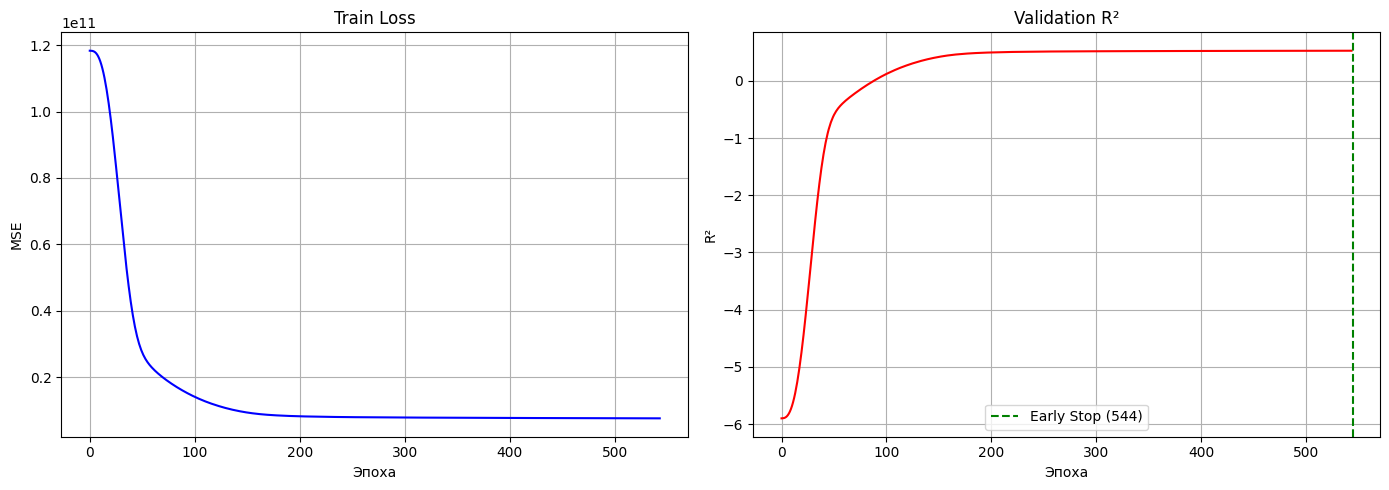

In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mlp.loss_curve_, color="blue")
ax1.set_title("Train Loss")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("MSE")
ax1.grid(True)

ax2.plot(mlp.validation_scores_, color="red")
ax2.axvline(x=mlp.n_iter_, color="green", linestyle="--", label=f"Early Stop ({mlp.n_iter_})")
ax2.set_title("Validation R²")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("R²")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 95241.37484920248
MSE: 15158448614.985218
RMSE: 123119.65161981745
R2: 0.5642622808893729


### MAE — Mean Absolute Error (Средняя абсолютная ошибка)

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### MSE — Mean Squared Error (Среднеквадратичная ошибка)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### RMSE — Root Mean Squared Error (Корень из MSE)
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### R² — Coefficient of Determination (Коэффициент детерминации)
Показывает, какую долю дисперсии целевой переменной объясняет модель. 
$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$